# Dataset

In [1]:
from pycaret.datasets import get_data
dataset = get_data('wine')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [2]:
dataset.shape

(6497, 13)

In [3]:
dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


***fixed acidity*** - most acids involved with wine or fixed or nonvolatile (do not evaporate readily)
***volatile acidity*** - the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
***citric acid*** - found in small quantities, citric acid can add 'freshness' and flavor to wines
***residual sugar*** - the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and wines with greater than 45 grams/liter are considered sweet
***chlorides*** - the amount of salt in the wine
***free sulfur dioxide*** - the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents microbial growth and the oxidation of wine
***total sulfur dioxide*** - amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2 concentrations over 50 ppm, SO2 becomes evident in the nose and taste of wine
***density*** - the density of water is close to that of water depending on the percent alcohol and sugar content
***pH*** - describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3 and 4 on the pH scale
***sulphates*** - a wine additive which can contribute to sulfur dioxide gas (S02) levels, which acts as an antimicrobial and antioxidant
***alcohol*** - the percent alcohol content of the wine
***quality*** - output variable (based on sensory data, score between 0 and 10)
***type*** - wine type (red or white)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


<AxesSubplot: title={'center': 'Quality Distribution'}, xlabel='Quality', ylabel='Count'>

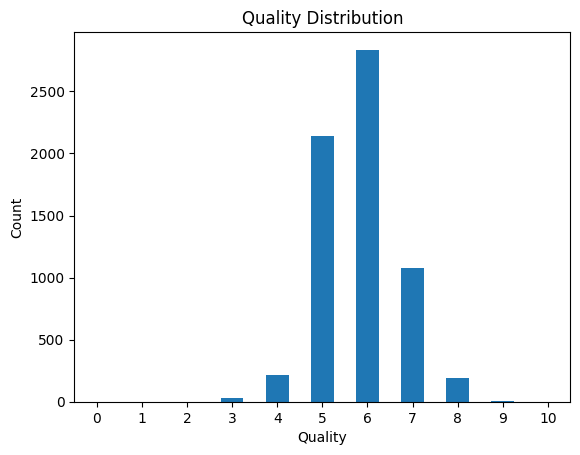

In [5]:
quality_distribution = dataset['quality'].value_counts()

# fill missing value counts with 0
for quality in range(0, 11):
    if quality not in quality_distribution:
        quality_distribution[quality] = 0

# sort by quality and plot
quality_distribution = quality_distribution.sort_index()
quality_distribution.plot(kind='bar', title='Quality Distribution', rot=0, xlabel='Quality', ylabel='Count')

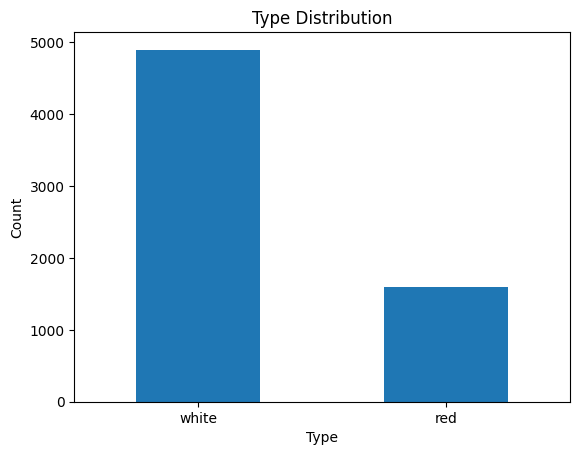

In [6]:
type_distribution = dataset['type'].value_counts()
plot = type_distribution.plot(kind='bar', title='Type Distribution', rot=0, xlabel='Type', ylabel='Count')

For this dataset it would be a good idea to predict wine quality based on the other features thus solving a regression problem. We won't be using wine type in model training as it is a categorical feature, and it doesn't influence wine quality.

# Data Preparation

In [7]:
from pycaret import regression
s = regression.setup(data=dataset, target='quality', session_id=5, ignore_features=['type'])

,Description,Value
0,session_id,5
1,Target,quality
2,Original Data,"(6497, 13)"
3,Missing Values,False
4,Numeric Features,11
5,Categorical Features,0
6,Ordinal Features,False
7,High Cardinality Features,False
8,High Cardinality Method,None
9,Transformed Train Set,"(4547, 11)"


# Compare Models

In [8]:
best = regression.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4064,0.3735,0.6109,0.5031,0.0928,0.0737,0.0820
rf,Random Forest Regressor,0.4497,0.3909,0.6249,0.4806,0.0949,0.0812,0.1450
lightgbm,Light Gradient Boosting Machine,0.4975,0.4338,0.6584,0.4231,0.0994,0.0891,0.0150
gbr,Gradient Boosting Regressor,0.5369,0.4773,0.6906,0.3655,0.1036,0.0957,0.0640
lr,Linear Regression,0.5678,0.5395,0.7340,0.2837,0.1100,0.1014,0.4250
lar,Least Angle Regression,0.5678,0.5395,0.7340,0.2837,0.1100,0.1014,0.0040
ridge,Ridge Regression,0.5698,0.5415,0.7354,0.2809,0.1101,0.1017,0.0040
br,Bayesian Ridge,0.5699,0.5416,0.7355,0.2808,0.1101,0.1017,0.0040
ada,AdaBoost Regressor,0.5777,0.5432,0.7368,0.2778,0.1106,0.1035,0.0340
huber,Huber Regressor,0.5721,0.5476,0.7395,0.2727,0.1106,0.1019,0.0120


In [9]:
best

ExtraTreesRegressor(bootstrap=False, ccp_alpha=0.0, criterion='mse',
                    max_depth=None, max_features='auto', max_leaf_nodes=None,
                    max_samples=None, min_impurity_decrease=0.0,
                    min_impurity_split=None, min_samples_leaf=1,
                    min_samples_split=2, min_weight_fraction_leaf=0.0,
                    n_estimators=100, n_jobs=-1, oob_score=False,
                    random_state=5, verbose=0, warm_start=False)

# Create Model

In [10]:
et = regression.create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4245,0.3910,0.6253,0.5039,0.0942,0.0760
1,0.4203,0.4003,0.6327,0.4725,0.0964,0.0764
2,0.4273,0.3753,0.6126,0.5175,0.0899,0.0747
3,0.4078,0.3719,0.6098,0.5183,0.0927,0.0740
4,0.4158,0.3701,0.6084,0.4791,0.0922,0.0758
5,0.3847,0.3537,0.5947,0.5278,0.0872,0.0670
6,0.3728,0.3326,0.5767,0.5253,0.0886,0.0673
7,0.4175,0.4035,0.6353,0.4264,0.0981,0.0778
8,0.3926,0.3777,0.6145,0.5381,0.0980,0.0755


In [11]:
et

ExtraTreesRegressor(bootstrap=False, ccp_alpha=0.0, criterion='mse',
                    max_depth=None, max_features='auto', max_leaf_nodes=None,
                    max_samples=None, min_impurity_decrease=0.0,
                    min_impurity_split=None, min_samples_leaf=1,
                    min_samples_split=2, min_weight_fraction_leaf=0.0,
                    n_estimators=100, n_jobs=-1, oob_score=False,
                    random_state=5, verbose=0, warm_start=False)

# Analyze Model

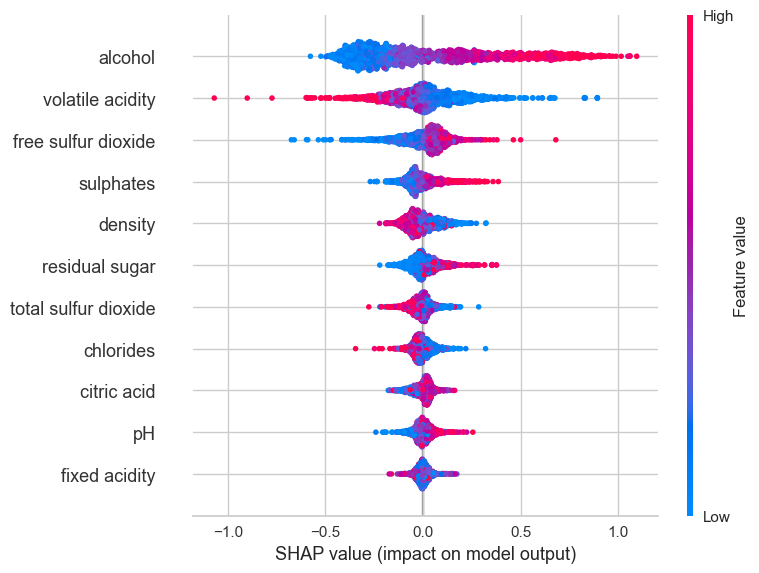

In [12]:
regression.interpret_model(et)

# Model Predictions

In [21]:
# predict on test set
predicted_quality = regression.predict_model(et).rename({'Label': 'predicted_quality'}, axis=1)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.3990,0.3620,0.6017,0.5369,0.0909,0.0721


In [22]:
predicted_quality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,predicted_quality
0,7.1,0.44,0.37,2.7,0.041,35.0,128.0,0.98960,3.07,0.43,13.5,7,7.00
1,9.2,0.36,0.34,1.6,0.062,5.0,12.0,0.99667,3.20,0.67,10.5,6,5.73
2,6.8,0.23,0.29,15.4,0.073,56.0,173.0,0.99840,3.06,0.41,8.7,6,6.00
3,7.0,0.22,0.31,2.7,0.030,41.0,136.0,0.98980,3.16,0.37,12.7,7,6.76
4,6.9,0.54,0.30,2.2,0.088,9.0,105.0,0.99725,3.25,1.18,10.5,6,5.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,7.1,0.28,0.26,1.9,0.049,12.0,86.0,0.99340,3.15,0.38,9.4,5,5.00
1946,7.1,0.43,0.25,2.8,0.036,43.0,132.0,0.98975,3.21,0.47,13.4,6,6.80
1947,7.0,0.35,0.31,1.8,0.069,15.0,162.0,0.99440,3.18,0.47,9.4,5,5.00
1948,6.0,0.27,0.28,4.8,0.063,31.0,201.0,0.99640,3.69,0.71,10.0,5,5.16


In [17]:
# finalize model
best_final = regression.finalize_model(et)

In [26]:
# predict on whole dataset
dataset_copy = dataset.copy().drop('quality', axis=1)
predictions = regression.predict_model(best_final, data=dataset_copy).rename({'Label': 'predicted_quality'}, axis=1)
predictions.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,predicted_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,red,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,red,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,red,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5.0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,red,5.0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,red,5.0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,red,7.0
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,red,7.0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,red,5.0


# Save model

In [27]:
regression.save_model(et, 'wine-quality-prediction-pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True,
                                       features_todrop=['type'], id_columns=[],
                                       ml_usecase='regression',
                                       numerical_features=[], target='quality',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_st...
                  ExtraTreesRegressor(bootstrap=False, ccp_alpha=0.0,
                                      criterion='mse', max_depth=None,
                                      max_features='auto', max_leaf_nodes=None,
                                      max_samples=Non

# load model

In [30]:
loaded_pipeline = regression.load_model('wine-quality-prediction-pipeline')

Transformation Pipeline and Model Successfully Loaded


In [31]:
loaded_pipeline

Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True,
                                      features_todrop=['type'], id_columns=[],
                                      ml_usecase='regression',
                                      numerical_features=[], target='quality',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                                fill_value_categorical=None,
                                fill_value_numerical=None,
                                numeric_st...
                 ExtraTreesRegressor(bootstrap=False, ccp_alpha=0.0,
                                     criterion='mse', max_depth=None,
                                     max_features='auto', max_leaf_nodes=None,
                                     max_samples=None,
              